In [ ]:
# ==================================================
# 1) Import Libraries
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==================================================
# 2) Upload Dataset
# ==================================================

from google.colab import files

uploaded = files.upload()

Saving churn_cleaned.csv to churn_cleaned.csv


In [ ]:
# ==================================================
# 3) Read Dataset
# ==================================================

df = pd.read_csv('churn_cleaned.csv')

In [ ]:
# ==================================================
# 4) Display First Rows
# ==================================================

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ==================================================
# 5) Dataset Information
# ==================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [ ]:
# ==================================================
# 6) Check Missing Values
# ==================================================

df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# ==================================================
# 7) Churn Distribution
# ==================================================

df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


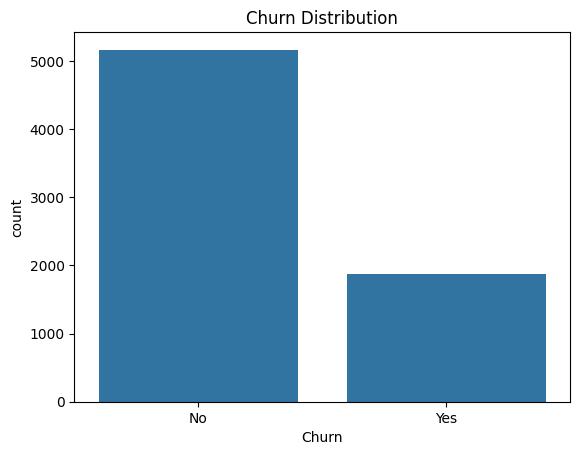

In [ ]:
# ==================================================
# 8) Visualization - Churn Count
# ==================================================

sns.countplot(x='Churn', data=df)

plt.title('Churn Distribution')

plt.show()

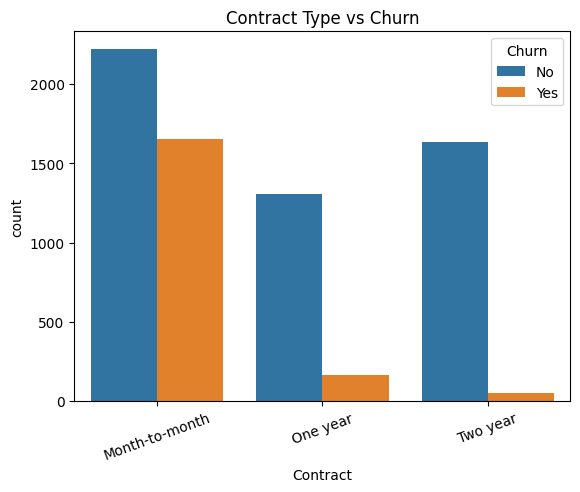

In [ ]:
# ==================================================
# 9) Visualization - Contract vs Churn
# ==================================================

sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title('Contract Type vs Churn')

plt.show()

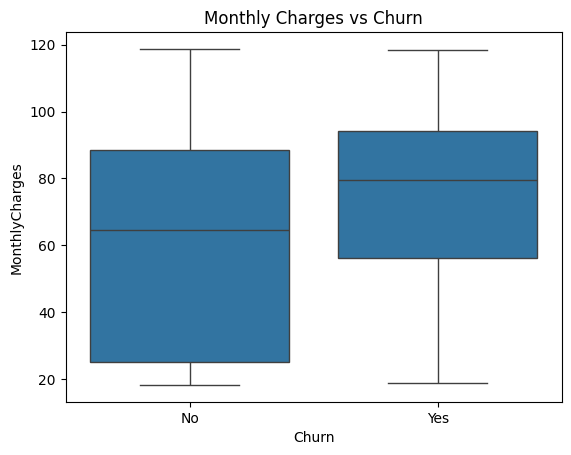

In [ ]:
# ==================================================
# 10) Visualization - Monthly Charges vs Churn
# ==================================================

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')

plt.show()

In [ ]:
# ==================================================
# 11) Convert TotalCharges to Numeric
# ==================================================

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# ==================================================
# 12) Remove Missing Values
# ==================================================

df = df.dropna()

In [ ]:
# ==================================================
# 13) Convert Churn to Numbers
# ==================================================

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [ ]:
# ==================================================
# 14) Convert Categorical Columns
# ==================================================

df = pd.get_dummies(df, drop_first=True)

In [ ]:
# ==================================================
# 15) Split Features and Target
# ==================================================

X = df.drop('Churn', axis=1)

y = df['Churn']

In [ ]:
# ==================================================
# 16) Split Train and Test Data
# ==================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# ==================================================
# 17) Feature Scaling
# ==================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
# ==================================================
# 18) Logistic Regression Model
# ==================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")

print("Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy:
0.7874911158493249

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



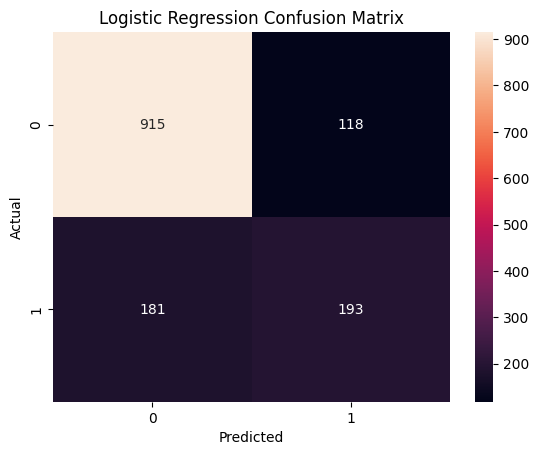

In [ ]:
# ==================================================
# 19) Logistic Regression Confusion Matrix Plot
# ==================================================

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==================================================
# 20) Decision Tree Model
# ==================================================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")

print("Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy:
0.7107320540156361

Confusion Matrix:
[[820 213]
 [194 180]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.46      0.48      0.47       374

    accuracy                           0.71      1407
   macro avg       0.63      0.64      0.64      1407
weighted avg       0.72      0.71      0.71      1407



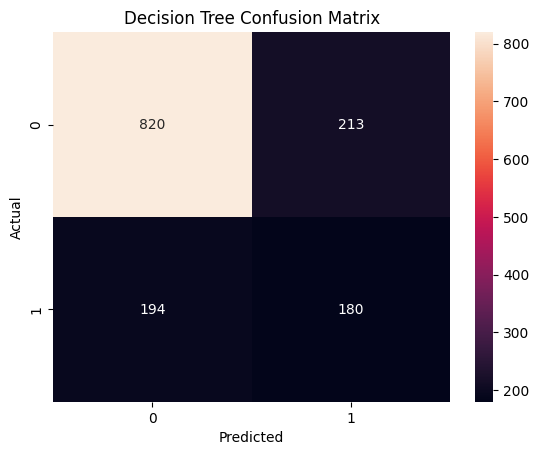

In [ ]:
# ==================================================
# 21) Decision Tree Confusion Matrix Plot
# ==================================================

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==================================================
# 22) Random Forest Model
# ==================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")

print("Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy:
0.7825159914712153

Confusion Matrix:
[[927 106]
 [200 174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



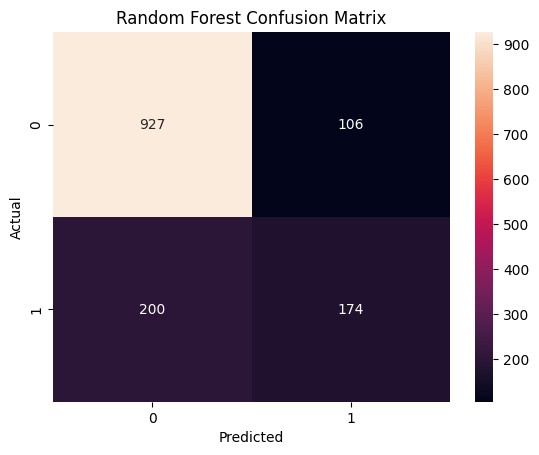

In [ ]:
# ==================================================
# 23) Random Forest Confusion Matrix Plot
# ==================================================

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==================================================
# 24) Final Accuracy Comparison
# ==================================================

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7874911158493249
Decision Tree Accuracy: 0.7107320540156361
Random Forest Accuracy: 0.7825159914712153


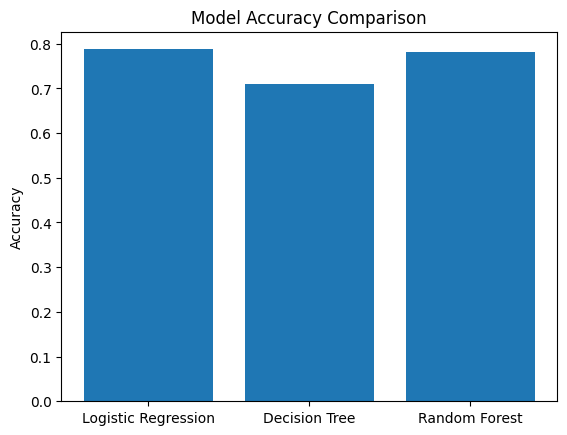

In [ ]:
# ==================================================
# 25) Accuracy Comparison Chart
# ==================================================

models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.show()

In [ ]:
# ==================================================
# 26) XGBoost Model
# ==================================================

!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")

print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy:
0.7739872068230277

Confusion Matrix:
[[903 130]
 [188 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



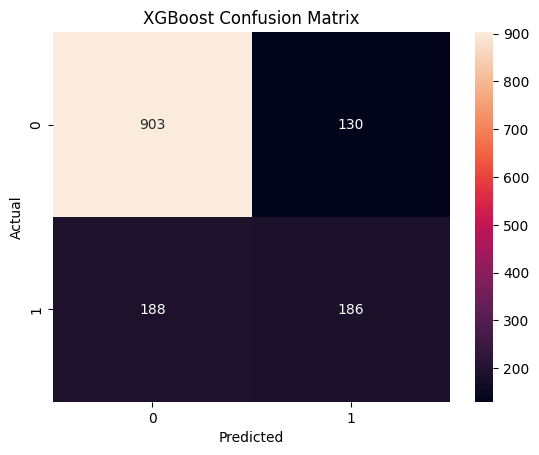

In [ ]:
# ==================================================
# 27) XGBoost Confusion Matrix Plot
# ==================================================

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

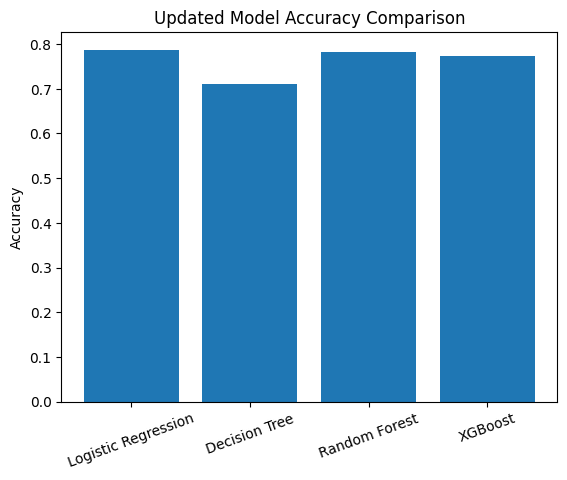

In [ ]:
# ==================================================
# 28) Updated Accuracy Comparison Chart
# ==================================================

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

plt.bar(models, accuracies)

plt.title('Updated Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.xticks(rotation=20)

plt.show()